# O6 Multimodal — 50 dimensions
Fixed depths 5, 10, 15, 20, 30 and staged `3 → 6 → 9 → 20`.

In [1]:
import json
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

HERE = Path.cwd()
if HERE.name != "04_50_dimensions":
    HERE = Path("/home/io632776/experiments/adaptive-smac/experiments/synthaticBench/o6_multi_modal/depth_policies/04_50_dimensions")
OUTPUT_DIRECTORY = HERE / "smac_output"
DIMENSION = 50
DEPTHS = (5, 10, 15, 20, 30)
FIXED = tuple(f"fixed_depth_{d}" for d in DEPTHS)
STAGED = "staged_depth_3_6_9_20"
LONG_STAGED = "staged_depth_5_10_15_20_every_500"
POLICIES = FIXED + (STAGED, LONG_STAGED)
SEEDS = tuple(range(5))
N_TRIALS = 2000
CHECKPOINTS = tuple(range(100, N_TRIALS + 1, 100))
LABELS = {f"fixed_depth_{d}": f"depth = {d}" for d in DEPTHS}
LABELS[STAGED] = "staged 3 → 6 → 9 → 20"
LABELS[LONG_STAGED] = "staged 5 → 10 → 15 → 20 / 500"
COLORS = dict(zip(POLICIES, ("C0", "C1", "C2", "C3", "C4", "black", "C6")))

In [2]:
def load(policy):
    runs = {}
    for path in (OUTPUT_DIRECTORY / policy).rglob("trajectory.json"):
        result = json.loads(path.read_text())
        if result["smac_seed"] in SEEDS and result["n_trials"] == N_TRIALS:
            runs[result["smac_seed"]] = result
    missing = sorted(set(SEEDS) - set(runs))
    if missing: raise FileNotFoundError(f"Missing {policy}: seeds={missing}")
    return runs

results = {p: load(p) for p in POLICIES}
for policy, runs in results.items():
    for result in runs.values():
        assert result["problem"] == "O6-Multimodal"
        assert result["dimension"] == DIMENSION
        assert result["problem_seed"] == 52
        assert result["initial_design"] == "random"
        assert result["n_initial_configs"] == 10
        assert result["initial_design_seed"] == result["smac_seed"]
        assert result["pythonhashseed"] == "12345"
        assert result["n_trials"] == N_TRIALS
        assert len(result["iteration"]) == N_TRIALS
        assert len(result["best_regret"]) == N_TRIALS
        if policy in FIXED: assert result["max_depth"] == int(policy.rsplit("_", 1)[1])
        elif policy == STAGED:
            assert result["stage_boundaries"] == [100, 200, 500]
            assert result["depth_schedule"] == [3, 6, 9, 20]
        else:
            assert result["stage_boundaries"] == [500, 1000, 1500]
            assert result["depth_schedule"] == [5, 10, 15, 20]
print(f"Loaded {sum(map(len, results.values()))}/35 trajectories.")

Loaded 35/35 trajectories.


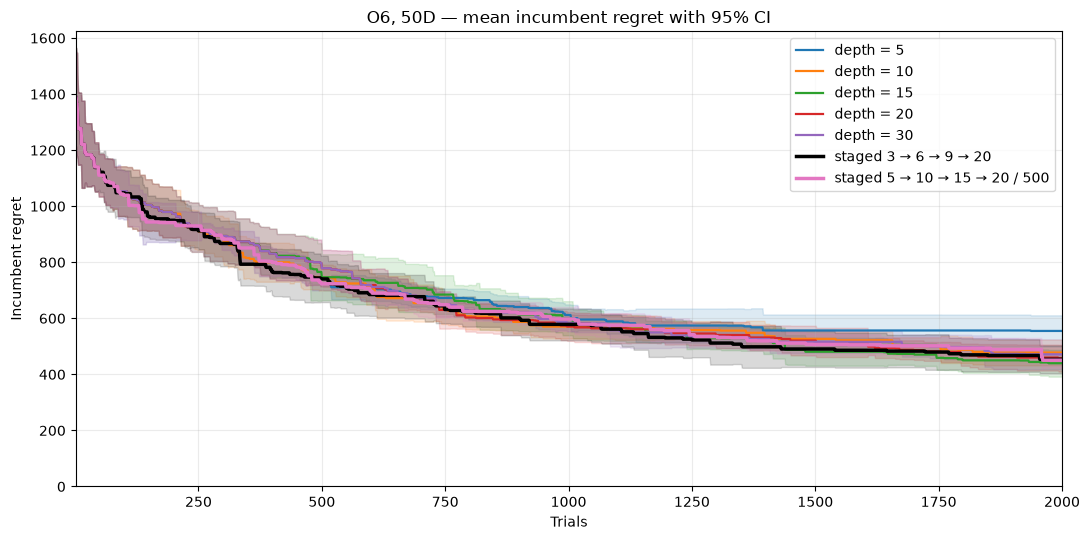

In [3]:
rows = [{"policy": p, "seed": s, "iteration": i, "best_regret": r} for p, runs in results.items() for s, result in runs.items() for i, r in zip(result["iteration"], result["best_regret"])]
trajectories = pd.DataFrame(rows)
summary = trajectories.groupby(["policy", "iteration"])["best_regret"].agg(["mean", "std", "count"]).reset_index()
summary["ci95"] = 1.96 * summary["std"] / np.sqrt(summary["count"])
fig, ax = plt.subplots(figsize=(11, 5.5))
for p in POLICIES:
    d = summary[summary.policy == p]
    ax.plot(d.iteration, d["mean"], label=LABELS[p], color=COLORS[p], linewidth=2.5 if p in (STAGED, LONG_STAGED) else 1.6)
    ax.fill_between(d.iteration, np.maximum(0, d["mean"]-d.ci95), d["mean"]+d.ci95, color=COLORS[p], alpha=.15)
ax.set(title=f"O6, {DIMENSION}D — mean incumbent regret with 95% CI", xlabel="Trials", ylabel="Incumbent regret", xlim=(1, N_TRIALS), ylim=(0,None)); ax.grid(alpha=.25); ax.legend(); plt.tight_layout(); plt.show()

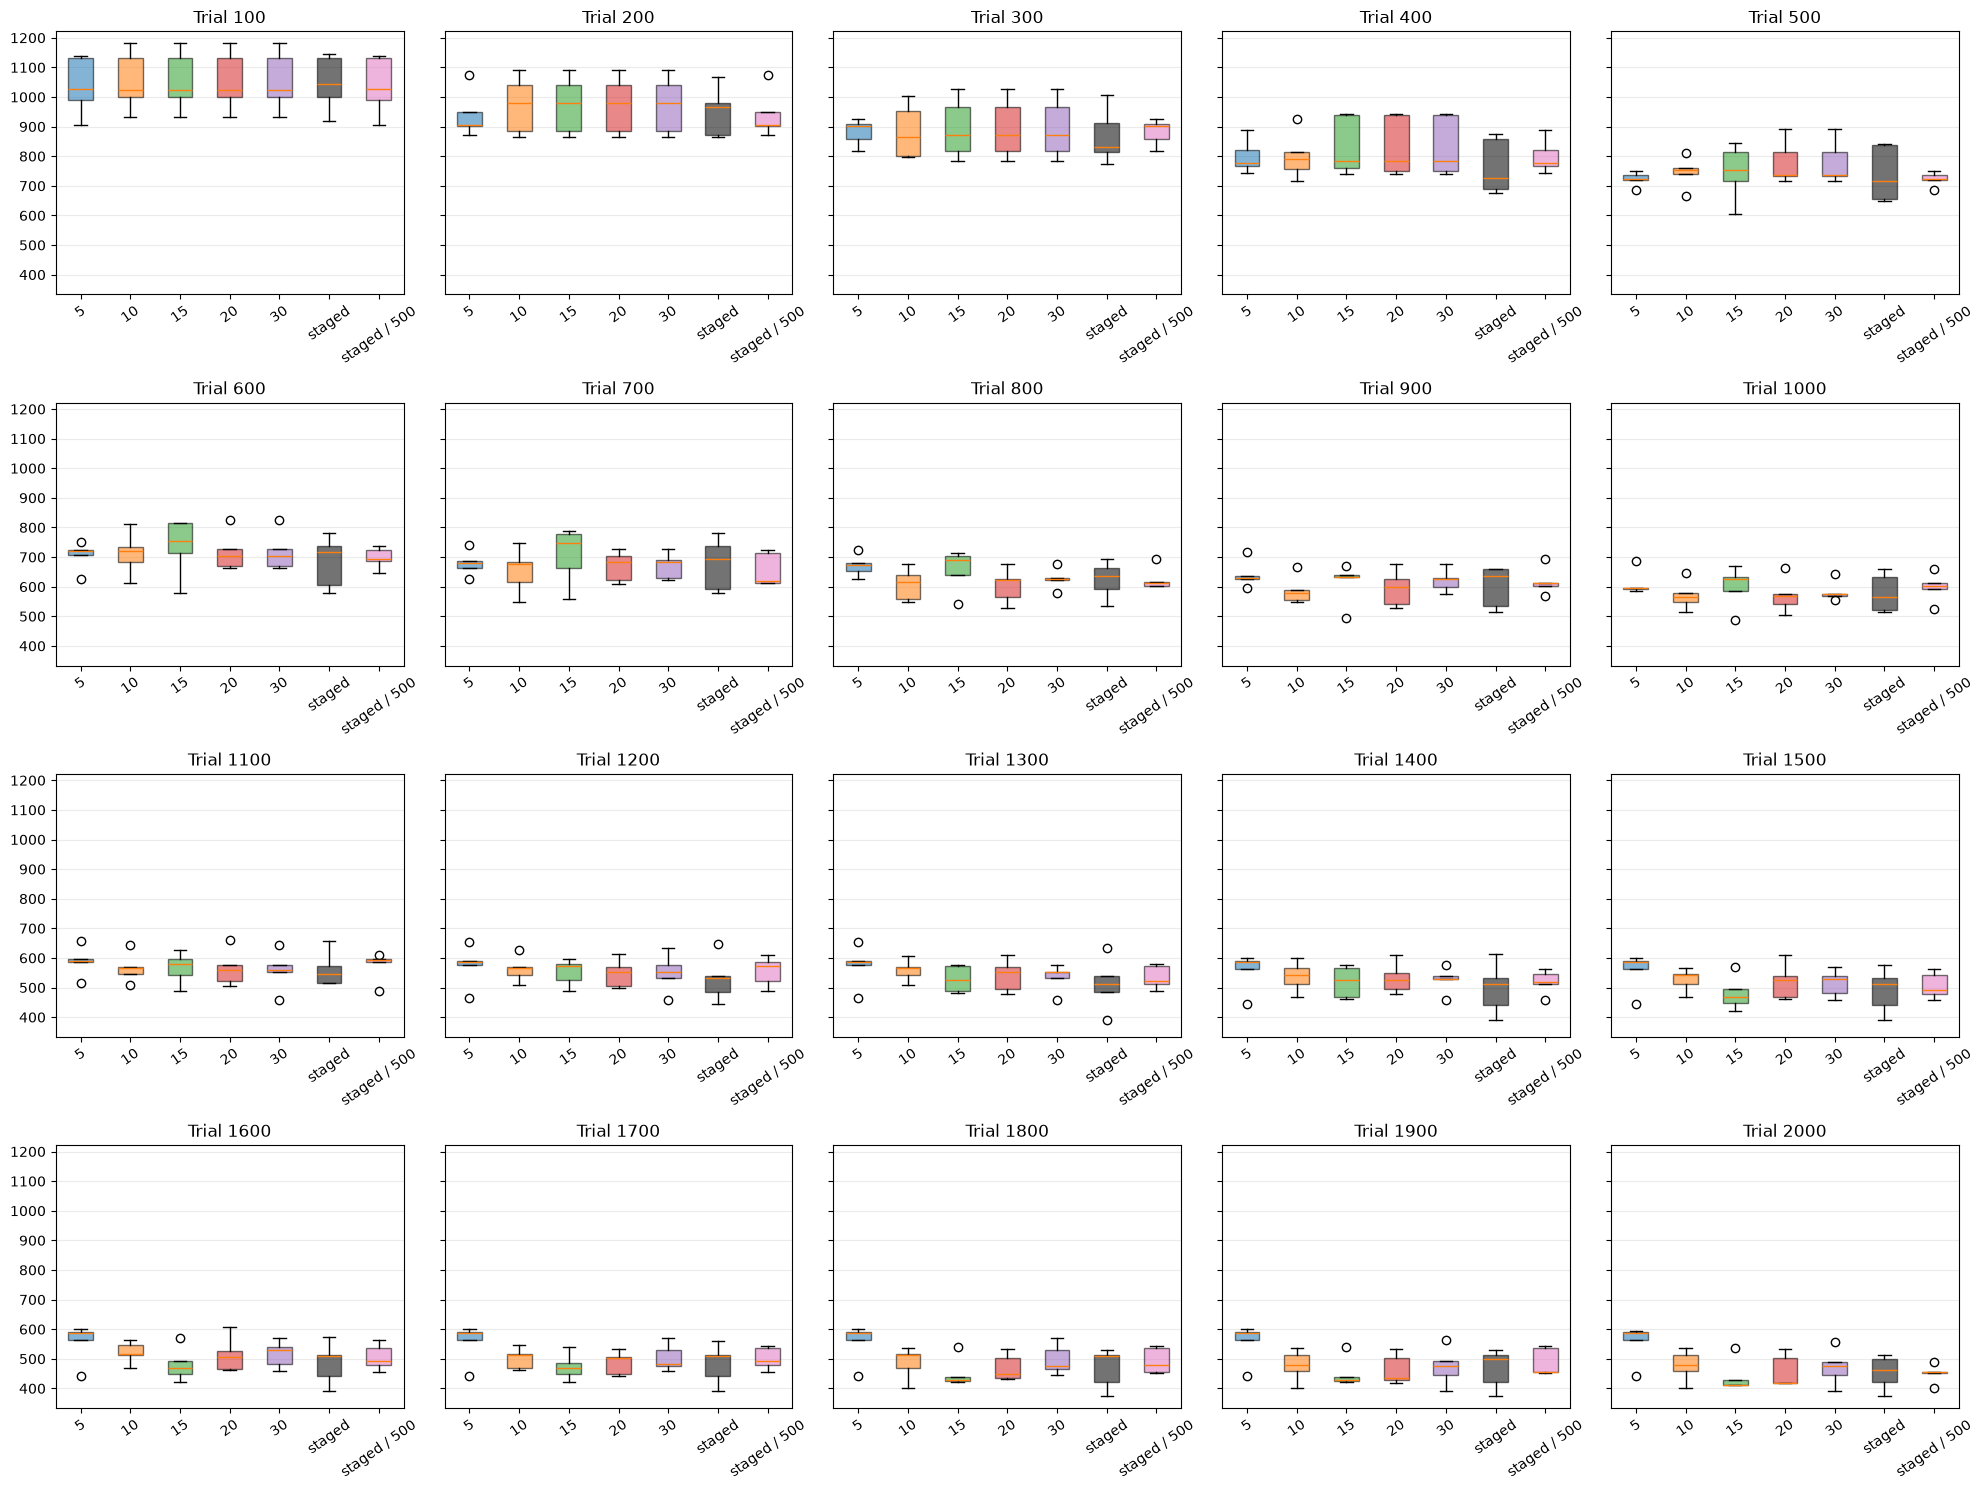

In [4]:
fig, axes = plt.subplots(4, 5, figsize=(20,15), sharey=True)
for ax, checkpoint in zip(axes.flat, CHECKPOINTS):
    values = [[results[p][s]["best_regret"][checkpoint-1] for s in SEEDS] for p in POLICIES]
    boxes = ax.boxplot(values, patch_artist=True, tick_labels=[str(d) for d in DEPTHS]+["staged", "staged / 500"])
    for box,p in zip(boxes["boxes"],POLICIES): box.set(facecolor=COLORS[p],alpha=.55)
    ax.set_title(f"Trial {checkpoint}"); ax.tick_params(axis="x",rotation=35); ax.grid(axis="y",alpha=.25)
plt.tight_layout(); plt.show()

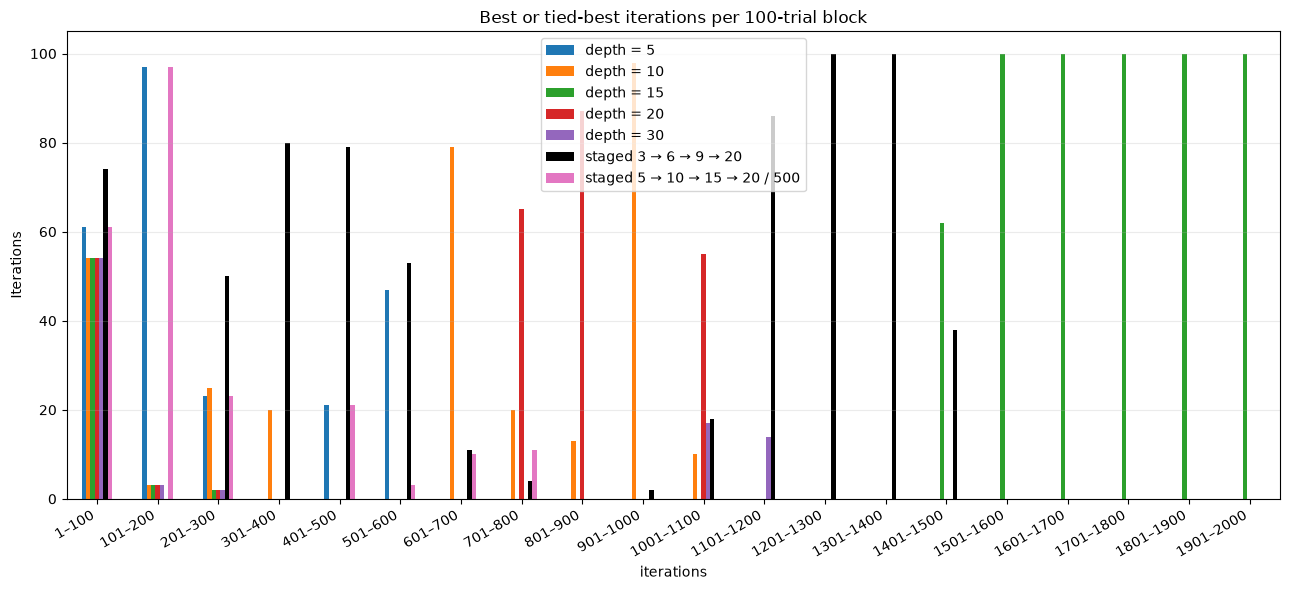

,iterations,superior policy,depth = 5,depth = 10,depth = 15,depth = 20,depth = 30,staged 3 → 6 → 9 → 20,staged 5 → 10 → 15 → 20 / 500
0,1–100,staged 3 → 6 → 9 → 20,61,54,54,54,54,74,61
1,101–200,"depth = 5, staged 5 → 10 → 15 → 20 / 500",97,3,3,3,3,0,97
2,201–300,staged 3 → 6 → 9 → 20,23,25,2,2,2,50,23
3,301–400,staged 3 → 6 → 9 → 20,0,20,0,0,0,80,0
4,401–500,staged 3 → 6 → 9 → 20,21,0,0,0,0,79,21
5,501–600,staged 3 → 6 → 9 → 20,47,0,0,0,0,53,3
6,601–700,depth = 10,0,79,0,0,0,11,10
7,701–800,depth = 20,0,20,0,65,0,4,11
8,801–900,depth = 20,0,13,0,87,0,0,0
9,901–1000,depth = 10,0,98,0,0,0,2,0


In [5]:
mean_regret = trajectories.pivot_table(index="iteration",columns="policy",values="best_regret",aggfunc="mean").reindex(columns=POLICIES)
best = mean_regret.min(axis=1)
wins = pd.DataFrame({p:np.isclose(mean_regret[p],best,rtol=1e-12,atol=1e-9) for p in POLICIES},index=mean_regret.index)
rows=[]
for end in CHECKPOINTS:
    counts=wins.loc[end-99:end].sum(); maximum=int(counts.max())
    row={"iterations":f"{end-99}–{end}","superior policy":", ".join(LABELS[p] for p in POLICIES if counts[p]==maximum)}
    row.update({LABELS[p]:int(counts[p]) for p in POLICIES}); rows.append(row)
block_superiority=pd.DataFrame(rows)
ax=block_superiority.set_index("iterations")[[LABELS[p] for p in POLICIES]].plot(kind="bar",figsize=(13,6),color=[COLORS[p] for p in POLICIES])
ax.set(title="Best or tied-best iterations per 100-trial block",ylabel="Iterations",ylim=(0,105)); ax.grid(axis="y",alpha=.25); plt.xticks(rotation=30,ha="right"); plt.tight_layout(); plt.show()
block_superiority

In [6]:
table = trajectories[trajectories.iteration.isin(CHECKPOINTS)].groupby(["iteration","policy"])["best_regret"].agg(["mean","std","min","median","max"])
with pd.option_context("display.max_rows",None,"display.max_columns",None,"display.width",None): display(table)

mean         std  \
iteration policy                                                       
100       fixed_depth_10                     1053.744483  101.215339   
          fixed_depth_15                     1053.744483  101.215339   
          fixed_depth_20                     1053.744483  101.215339   
          fixed_depth_30                     1053.744483  101.215339   
          fixed_depth_5                      1039.172391   98.481416   
          staged_depth_3_6_9_20              1047.640503   94.538605   
          staged_depth_5_10_15_20_every_500  1039.172391   98.481416   
200       fixed_depth_10                      973.165128   97.029750   
          fixed_depth_15                      973.165128   97.029750   
          fixed_depth_20                      973.165128   97.029750   
          fixed_depth_30                      973.165128   97.029750   
          fixed_depth_5                       941.559784   79.868558   
          staged_depth_3_6_9_20               949.761961   83.008929   
          staged_depth_5_10_15_20_every_500   941.559784   79.868558   
300       fixed_depth_10                      883.582658   92.072647   
          fixed_depth_15                      893.639043  102.116349   
          fixed_depth_20                      893.639043  102.116349   
          fixed_depth_30                      893.639043  102.116349   
          fixed_depth_5                       882.567800   44.217353   
          staged_depth_3_6_9_20               867.077392   92.959347   
          staged_depth_5_10_15_20_every_500   882.567800   44.217353   
400       fixed_depth_10                      800.069210   79.346231   
          fixed_depth_15                      832.561736  100.037127   
          fixed_depth_20                      830.717958  101.784928   
          fixed_depth_30                      830.717958  101.784928   
          fixed_depth_5                       799.499778   57.966003   
          staged_depth_3_6_9_20               765.478287   93.994624   
          staged_depth_5_10_15_20_every_500   799.499778   57.966003   
500       fixed_depth_10                      745.703235   52.935937   
          fixed_depth_15                      746.673348   93.735376   
          fixed_depth_20                      778.773119   74.633299   
          fixed_depth_30                      778.773119   74.633299   
          fixed_depth_5                       723.306668   25.036857   
          staged_depth_3_6_9_20               740.504678   94.250917   
          staged_depth_5_10_15_20_every_500   723.306668   25.036857   
600       fixed_depth_10                      712.229426   72.859594   
          fixed_depth_15                      735.862063   97.600056   
          fixed_depth_20                      718.614653   65.690933   
          fixed_depth_30                      718.614653   65.690933   
          fixed_depth_5                       705.708984   47.974333   
          staged_depth_3_6_9_20               684.968620   87.219663   
          staged_depth_5_10_15_20_every_500   697.055034   35.921952   
700       fixed_depth_10                      654.440478   75.514525   
          fixed_depth_15                      707.371824   97.475540   
          fixed_depth_20                      669.330937   52.186839   
          fixed_depth_30                      670.748012   44.580707   
          fixed_depth_5                       678.941633   42.065924   
          staged_depth_3_6_9_20               677.218713   88.873925   
          staged_depth_5_10_15_20_every_500   656.500510   56.923707   
800       fixed_depth_10                      607.836114   53.563647   
          fixed_depth_15                      657.693592   70.757395   
          fixed_depth_20                      602.874102   57.292233   
          fixed_depth_30                      625.882729   34.537130   
          fixed_depth_5                       670.845009   36.259531   
          staged_dep